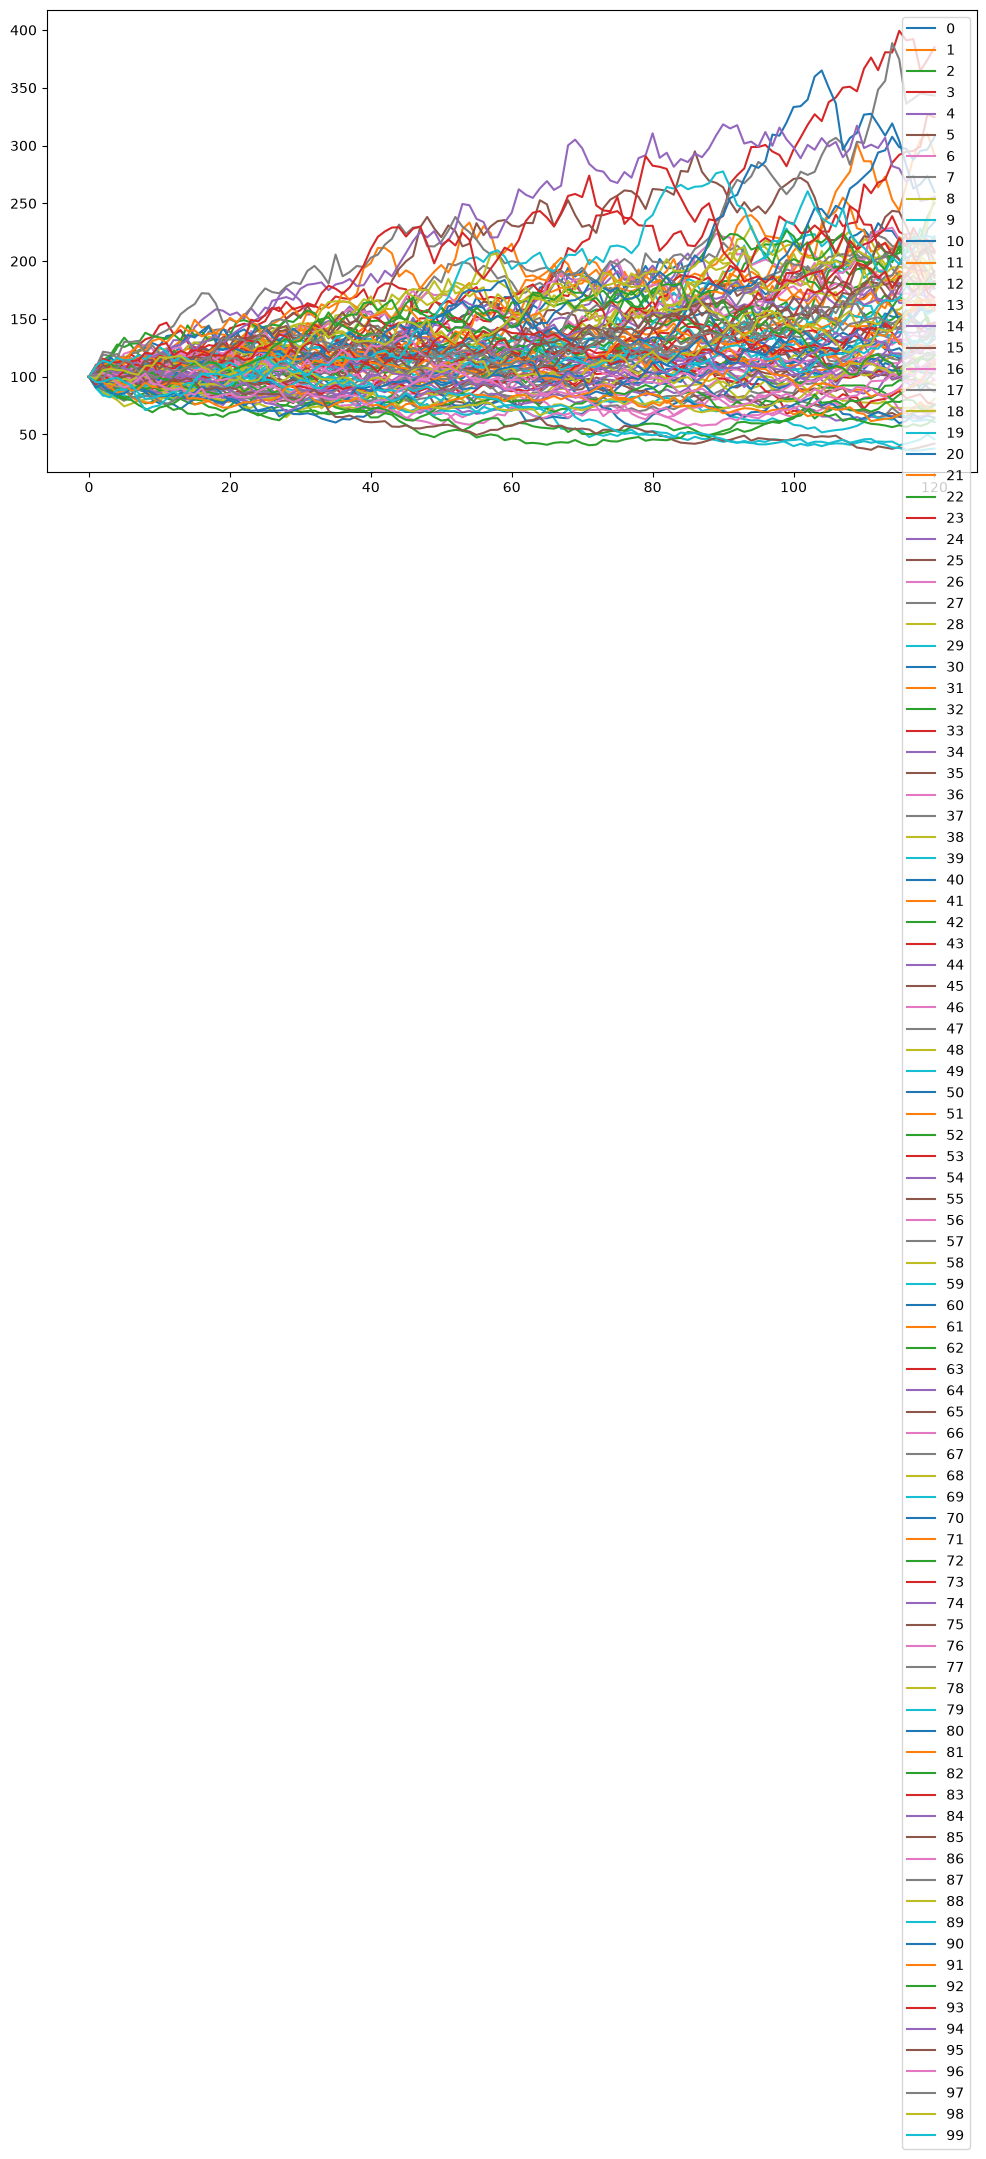

In [3]:

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import time

import ipywidgets as widgets


# Geometric Stochastic Brownian Motion Discrete Time Simulation:
# Creates a set of random data points (based on stochastic brownian motion) for every step in a certain number of years (default 12 and 10 respectively)
# def gbm(n_years=10,mu=0.07, sigma=0.15, steps_per_year=12):
#     dt = 1/steps_per_year
#     n_steps = n_years*steps_per_year
#     xi = np.random.normal(size=n_steps)
#     returns = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
#     return pd.DataFrame(returns)

# rets = gbm()
# #Transform the returns into a wealth index
# wealth_index = (1+rets).cumprod()
# plt.plot(wealth_index)
# plt.show()

#Added multiple scenarios to the graph
# def gbm(n_years=10, n_scenarios=100, mu=0.05, sigma=0.15, steps_per_year=12, start_price = 100):
#     dt = 1/steps_per_year
#     n_steps = n_years*steps_per_year
#     xi = np.random.normal(size=(n_steps,n_scenarios))
#     returns = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
#     returns = pd.DataFrame(returns)
#     return start_price * (1+returns).cumprod()

# rets = gbm()
# plt.figure(figsize=(12,6))
# plt.plot(rets)
# plt.legend(rets)
# plt.show()

#Refined function to decrease the amount of broadcasting to be done on dataFrames and offloads the work to faster numpy functions
# def gbm(n_years=10, n_scenarios=100, mu=0.05, sigma=0.15, steps_per_year=12, start_price = 100):
#     dt = 1/steps_per_year
#     n_steps = n_years*steps_per_year
#     returns = np.random.normal(loc= ((1+mu)**dt), scale= (sigma*np.sqrt(dt)), size=(n_steps,n_scenarios))
#     return start_price*pd.DataFrame(returns).cumprod()

#Improved function that starts all walks on 1 instead of their first data point
def gbm(n_years=10, n_scenarios=100, mu=0.05, sigma=0.15, steps_per_year=12, start_price = 100):
    dt = 1/steps_per_year
    n_steps = n_years*steps_per_year
    returns = np.random.normal(loc= ((1+mu)**dt), scale= (sigma*np.sqrt(dt)), size=(n_steps,n_scenarios))
    returns = pd.concat([pd.DataFrame(np.ones((1,n_scenarios))), pd.DataFrame(returns)], ignore_index=True)
    return start_price*returns.cumprod()

rets = gbm()
plt.figure(figsize=(12,6))
plt.plot(rets)
plt.legend(rets)
plt.show()


In [1]:
def func(n):
    return n*2

In [ ]:
#Just a test function to make sure interactive python shell is working with widgets
widgets.interact(func, n=(0,100,2))


interactive(children=(IntSlider(value=50, description='n', step=2), Output()), _dom_classes=('widget-interact'…

<function __main__.func(n)>

In [19]:
import matplotlib as plt

In [ ]:
# Function
def interactive_gbm(mu=0.07, sigma=0.15, n_years= 10, n_scenarios= 100, start_principal =100, steps_per_year =12):
    prices = gbm(n_years, n_scenarios, mu, sigma, steps_per_year, start_principal)
    terminal_wealth = prices.iloc[-1]

    fig, (wealth_axis, hist_axis) = plt.pyplot.subplots(nrows=1, ncols=2, sharey=True, figsize=(24,10), gridspec_kw={'width_ratios':[3,1]})
    plt.pyplot.subplots_adjust(wspace=0)
    prices.plot(legend=False, ax=wealth_axis, color ='skyblue')
    wealth_axis.axhline(y=start_principal, ls='--', color = 'black')
    terminal_wealth.plot.hist(ax=hist_axis, bins =50, ec='white', orientation='horizontal', color='skyblue')



In [ ]:
widgets.interactive(interactive_gbm, mu=(-0.1,.2, 0.01), sigma=(0, 0.30,0.01), n_years= (1,30,1), n_scenarios= (1, 1000), start_principal =(1 ,1000), steps_per_year =12)

interactive(children=(FloatSlider(value=0.07, description='mu', max=0.2, min=-0.1, step=0.01), FloatSlider(val…